Student Health Condition Prediction Model
Analisis pengaruh lifestyle & physiological terhadap kesehatan mahasiswa
Dataset: 50,000 records | Target: health_condition (Fit / At-Risk / Unhealthy)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

In [6]:
!pip install xlrd

In [7]:
df = pd.read_csv('/content/enhanced_student_health_dataset_50k.xls')

In [8]:
df.head(10)

,student_id,timestamp,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,screen_time,...,stress_level,sleep_quality,physical_activity_level,smoking_status,alcohol_intake,mental_health_status,academic_pressure,social_relationships,gender,health_condition
0,2126,2025-01-01 00:00:00,7.344381,63.590449,23.694383,1722.960374,13779,29.794434,2.595907,7.360444,...,medium,average,sedentary,yes,no,moderate,low,average,male,fit
1,2459,2025-01-01 01:00:00,6.642634,76.907947,20.897437,1861.774447,1980,59.226722,1.487538,6.601933,...,low,poor,moderate,no,high,poor,medium,average,other,fit
2,1860,2025-01-01 02:00:00,6.821261,65.867357,28.609537,1425.928398,5728,77.926708,2.694572,8.614042,...,low,good,active,no,moderate,stable,high,average,other,fit
3,2294,2025-01-01 03:00:00,6.911760,62.742439,20.145188,2612.837847,4197,70.180605,0.891084,6.024259,...,high,poor,sedentary,yes,no,moderate,medium,good,male,at-risk
4,2130,2025-01-01 04:00:00,7.419652,81.226679,23.253223,2336.351853,9952,76.657675,4.310637,6.735069,...,medium,good,active,no,high,moderate,medium,average,female,fit
5,2095,2025-01-01 05:00:00,5.561019,93.230547,21.101055,2531.846410,10882,24.765725,2.719121,3.114103,...,high,good,sedentary,no,high,moderate,high,poor,male,unhealthy
6,2724,2025-01-01 06:00:00,4.801989,71.129658,20.876263,2368.551434,6261,52.269709,1.946149,4.330838,...,medium,good,active,no,no,moderate,medium,good,female,fit
7,2044,2025-01-01 07:00:00,7.981446,80.807539,23.997833,2241.143958,4308,31.162193,2.489282,3.418336,...,medium,good,active,yes,moderate,stable,medium,good,female,fit
8,2638,2025-01-01 08:00:00,8.347186,79.837429,25.838189,2424.461606,4665,49.373457,1.468703,5.282541,...,medium,poor,active,occasional,no,poor,high,average,male,at-risk
9,1121,2025-01-01 09:00:00,8.118454,76.739958,24.995595,2625.849905,6204,38.568077,3.321817,2.024493,...,low,average,sedentary,no,no,poor,high,good,other,at-risk


In [9]:
df.tail(10)

,student_id,timestamp,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,screen_time,...,stress_level,sleep_quality,physical_activity_level,smoking_status,alcohol_intake,mental_health_status,academic_pressure,social_relationships,gender,health_condition
49990,2724,2030-09-14 22:00:00,5.135914,56.907499,24.856487,2359.552586,5261,36.426166,3.019751,3.709089,...,medium,average,active,occasional,moderate,moderate,medium,good,female,fit
49991,1952,2030-09-14 23:00:00,6.551387,70.417737,22.047246,2928.349591,14882,60.615445,2.287552,4.853919,...,medium,average,moderate,occasional,moderate,stable,low,average,male,fit
49992,1818,2030-09-15 00:00:00,9.773944,75.365689,20.884507,1969.615291,11958,81.667973,0.932121,5.108816,...,medium,poor,moderate,yes,moderate,poor,medium,poor,female,fit
49993,1215,2030-09-15 01:00:00,6.581697,86.952750,23.887215,2323.699957,3838,13.226183,2.156286,3.774319,...,low,good,active,occasional,no,moderate,low,average,male,fit
49994,2426,2030-09-15 02:00:00,4.730823,78.672866,23.590947,1604.387391,4937,41.895884,2.197538,2.253046,...,medium,good,moderate,no,no,moderate,high,good,female,at-risk
49995,1282,2030-09-15 03:00:00,6.461986,68.226449,24.861975,2453.816745,2924,67.284851,2.168705,2.924262,...,high,poor,active,yes,high,stable,medium,poor,other,fit
49996,2854,2030-09-15 04:00:00,9.592059,66.537953,19.531005,2537.610050,9612,37.892820,2.263300,5.028701,...,low,average,moderate,yes,no,moderate,high,poor,male,fit
49997,2979,2030-09-15 05:00:00,4.610607,76.923209,25.548757,1625.662097,3986,60.659020,1.836763,5.691189,...,high,poor,sedentary,yes,moderate,poor,low,good,female,unhealthy
49998,2596,2030-09-15 06:00:00,6.998592,71.458365,22.505657,3028.446887,1035,48.645693,2.187727,2.458848,...,medium,average,sedentary,no,no,stable,medium,average,female,fit
49999,1572,2030-09-15 07:00:00,8.106611,95.901802,21.364388,1654.898477,9651,40.095220,2.707838,0.000000,...,high,good,sedentary,no,high,poor,medium,good,female,at-risk


EDA

In [10]:
df.shape


(50000, 22)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               50000 non-null  int64  
 1   timestamp                50000 non-null  object 
 2   sleep_duration           50000 non-null  float64
 3   heart_rate               50000 non-null  float64
 4   bmi                      50000 non-null  float64
 5   calorie_expenditure      50000 non-null  float64
 6   step_count               50000 non-null  int64  
 7   exercise_duration        50000 non-null  float64
 8   water_intake             50000 non-null  float64
 9   screen_time              50000 non-null  float64
 10  sitting_time             50000 non-null  float64
 11  diet_type                50000 non-null  object 
 12  stress_level             50000 non-null  object 
 13  sleep_quality            50000 non-null  object 
 14  physical_activity_leve

In [12]:
df.describe()

,student_id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,screen_time,sitting_time
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,6.989631,75.049457,23.005577,2199.727792,7984.535900,40.123596,2.202735,4.999897,7.990199
std,575.513241,1.465515,9.960752,2.966889,397.489825,4044.586246,19.586029,0.697176,2.002285,2.003774
min,1000.000000,3.000000,50.000000,16.000000,1200.000000,1000.000000,0.000000,0.500000,0.000000,2.000000
25%,1513.000000,5.977321,68.326796,20.967067,1930.918830,4438.000000,26.547306,1.726309,3.640515,6.638104
50%,2007.000000,7.007309,75.036996,22.979486,2201.853398,8004.000000,39.912727,2.203305,4.987757,7.999825
75%,2506.000000,8.017022,81.739695,25.014956,2469.340409,11481.000000,53.348052,2.674900,6.360283,9.341209
max,2999.000000,10.000000,117.020259,35.000000,3712.875140,14999.000000,120.000000,5.000000,12.000000,16.000000


In [13]:
df.isnull().sum()

,0
student_id,0
timestamp,0
sleep_duration,0
heart_rate,0
bmi,0
calorie_expenditure,0
step_count,0
exercise_duration,0
water_intake,0
screen_time,0


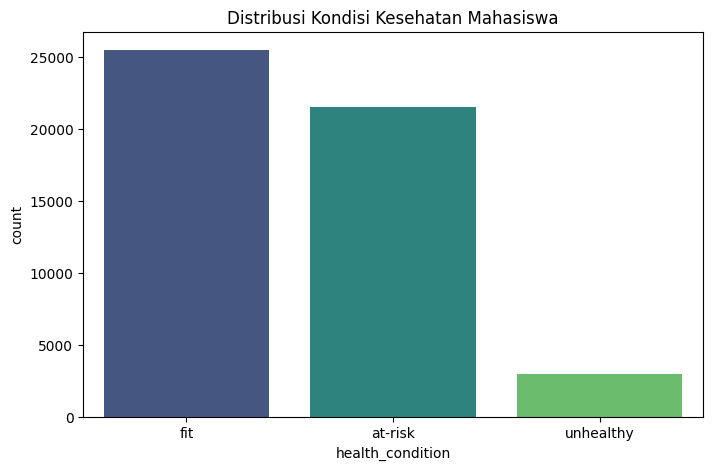

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='health_condition', palette='viridis')
plt.title('Distribusi Kondisi Kesehatan Mahasiswa')
plt.show()

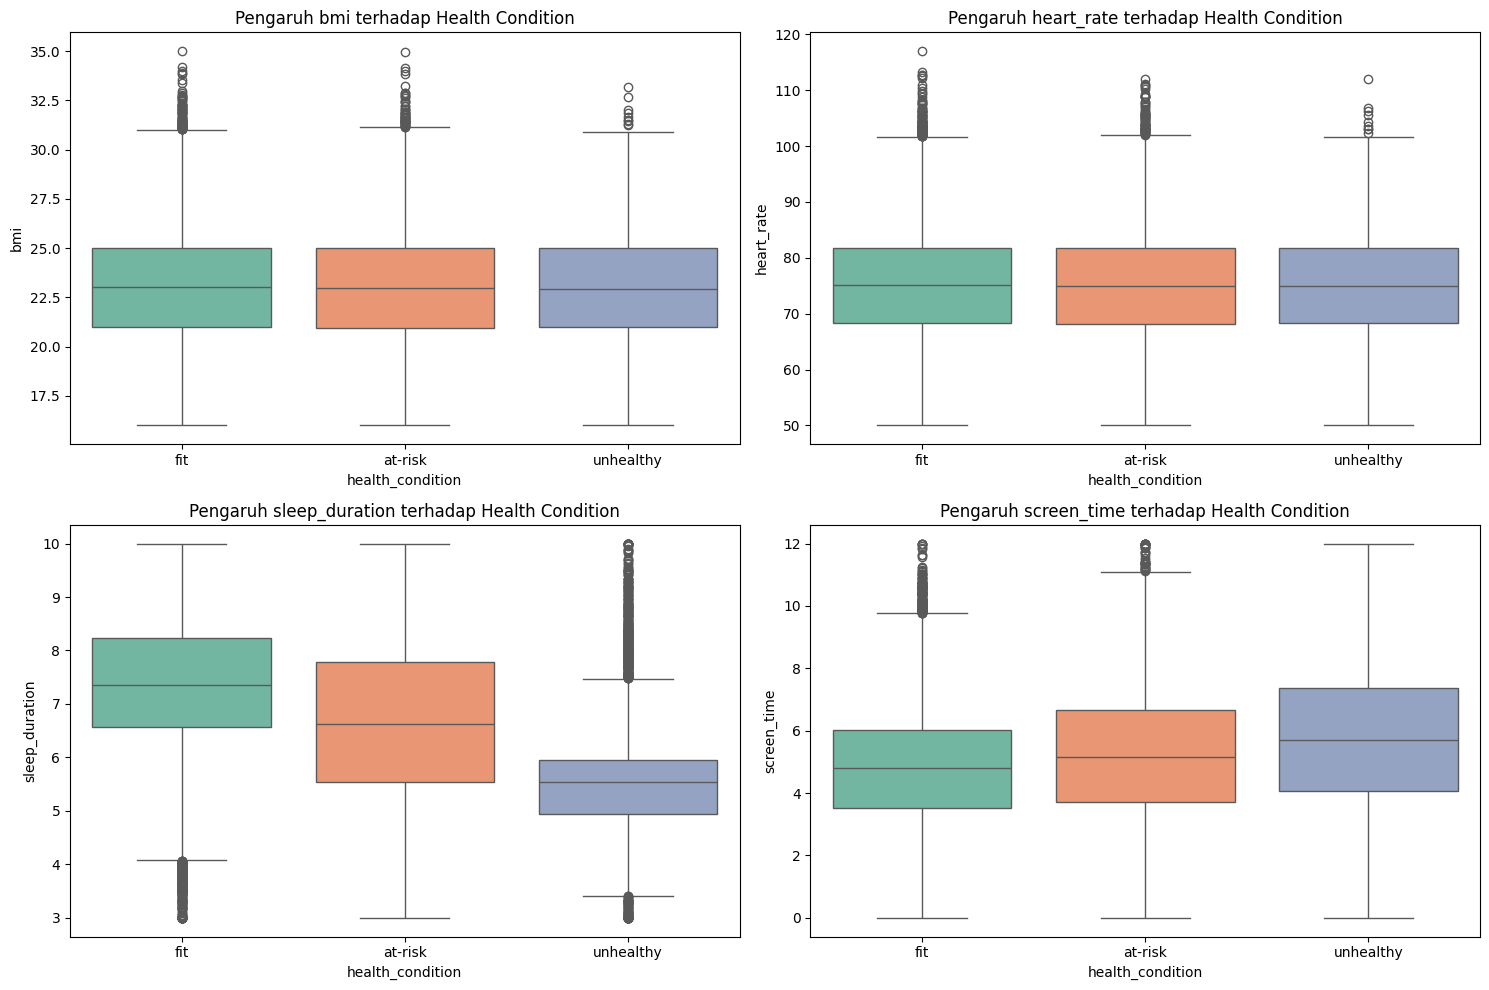

In [15]:

physio_features = ['bmi', 'heart_rate', 'sleep_duration', 'stress_level']

plt.figure(figsize=(15, 10))
for i, col in enumerate(['bmi', 'heart_rate', 'sleep_duration', 'screen_time'], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='health_condition', y=col, palette='Set2')
    plt.title(f'Pengaruh {col} terhadap Health Condition')

plt.tight_layout()
plt.show()

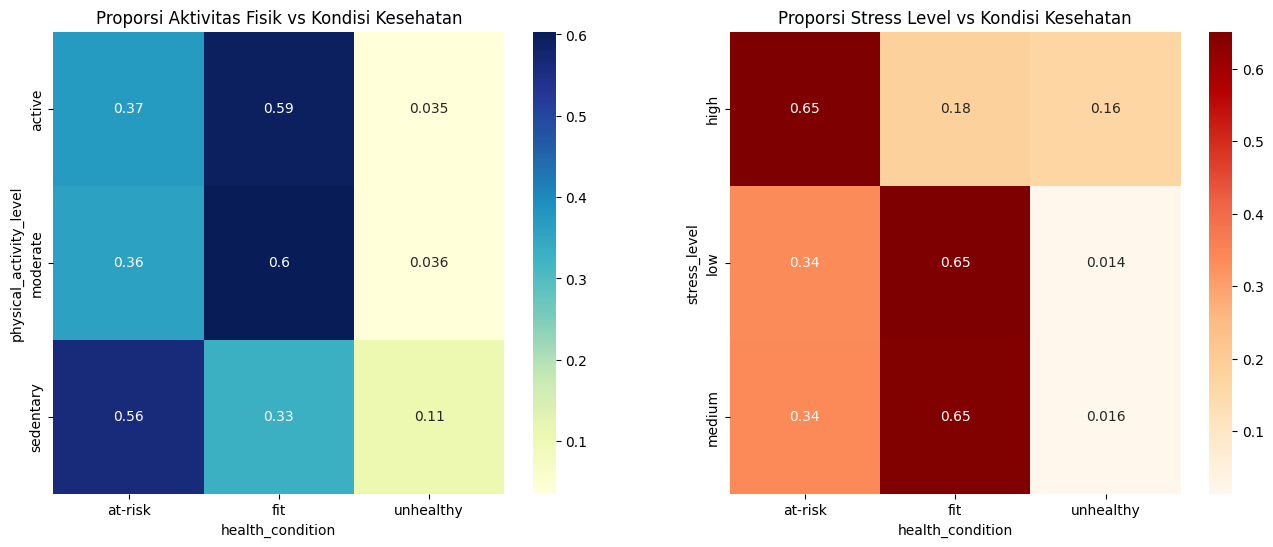

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap antara Aktivitas Fisik dan Kondisi Kesehatan
ct_activity = pd.crosstab(df['physical_activity_level'], df['health_condition'], normalize='index')
sns.heatmap(ct_activity, annot=True, cmap='YlGnBu', ax=ax[0])
ax[0].set_title('Proporsi Aktivitas Fisik vs Kondisi Kesehatan')

# Heatmap antara Stress Level dan Kondisi Kesehatan
ct_stress = pd.crosstab(df['stress_level'], df['health_condition'], normalize='index')
sns.heatmap(ct_stress, annot=True, cmap='OrRd', ax=ax[1])
ax[1].set_title('Proporsi Stress Level vs Kondisi Kesehatan')

plt.show()

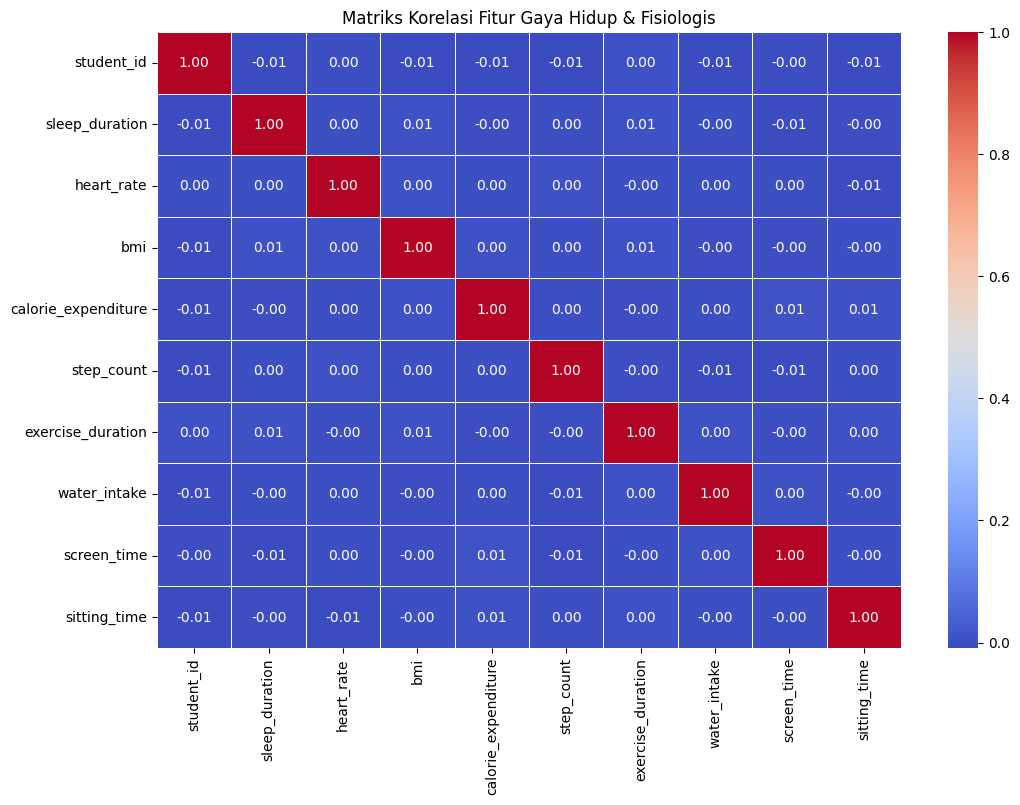

In [17]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Gaya Hidup & Fisiologis')
plt.show()

In [18]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['day_name'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month
df['month_name'] = df['timestamp'].dt.month_name()

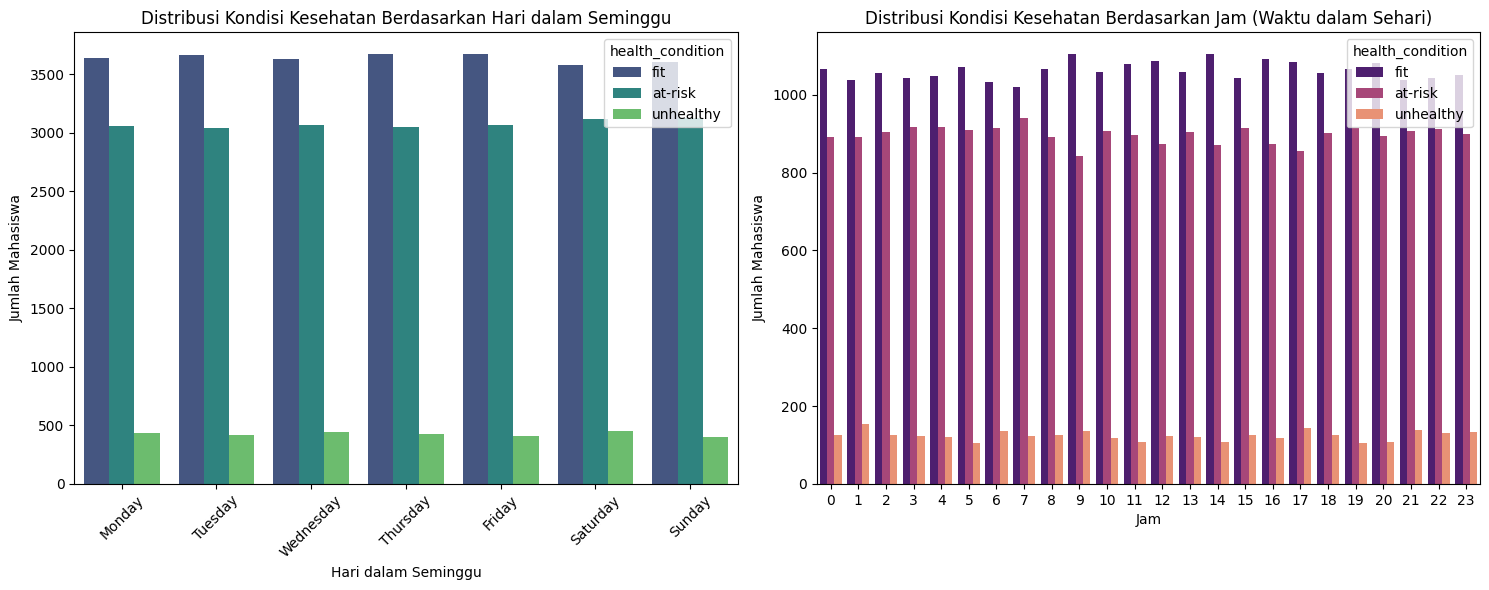

In [19]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='day_name', hue='health_condition', palette='viridis', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Distribusi Kondisi Kesehatan Berdasarkan Hari dalam Seminggu')
plt.xlabel('Hari dalam Seminggu')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='hour', hue='health_condition', palette='magma')
plt.title('Distribusi Kondisi Kesehatan Berdasarkan Jam (Waktu dalam Sehari)')
plt.xlabel('Jam')
plt.ylabel('Jumlah Mahasiswa')

plt.tight_layout()
plt.show()

PREPROCESSING

In [20]:
df.drop(columns=["student_id", "timestamp"], inplace=True)

In [21]:
target_col = 'health_condition'
feature_categorical_cols = [col for col in df.select_dtypes(include='object').columns.tolist() if col != target_col]

le_dict = {}
for col in feature_categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
if df[target_col].dtype == 'object':
    le_target = LabelEncoder()
    df[target_col] = le_target.fit_transform(df[target_col])
    class_names = le_target.classes_
else:
    pass

In [22]:
if 'class_names' in globals():
    print(f"[INFO] Target classes: {class_names}")
else:
    print("[INFO] Target classes could not be determined. The target column 'health_condition' might have already been numerical, preventing the assignment of 'class_names' in the previous step.")

[INFO] Target classes: ['at-risk' 'fit' 'unhealthy']


In [23]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"[INFO] Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

[INFO] Train: 40000 | Test: 10000


Model Training

In [25]:
from sklearn.impute import SimpleImputer

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500, random_state=42, multi_class="auto"))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, max_depth=15,
                                        random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                            max_depth=5, random_state=42))
    ]),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n[TRAINING] Cross-Validation (5-fold)...")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"  {name:25s} | Acc: {scores.mean():.4f} \u00b1 {scores.std():.4f}")


[TRAINING] Cross-Validation (5-fold)...
  Logistic Regression       | Acc: 0.6999 ± 0.0034
  Random Forest             | Acc: 0.9942 ± 0.0015
  Gradient Boosting         | Acc: 0.9997 ± 0.0002


Evaluating the Best Model

[INFO] Best model identified: Gradient Boosting

[EVALUATION] Gradient Boosting Performance on Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4308
           1       1.00      1.00      1.00      5096
           2       1.00      1.00      1.00       596

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



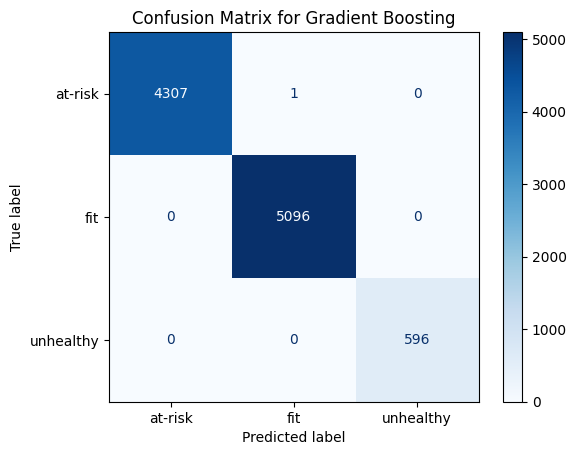

In [26]:
best_model_name = max(results, key=lambda k: results[k].mean())
best_model_pipeline = models[best_model_name]

print(f"[INFO] Best model identified: {best_model_name}")

best_model_pipeline.fit(X_train, y_train)

y_pred = best_model_pipeline.predict(X_test)

print(f"\n[EVALUATION] {best_model_name} Performance on Test Set:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names if 'class_names' in globals() else ['0', '1', '2'])
display.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.show()

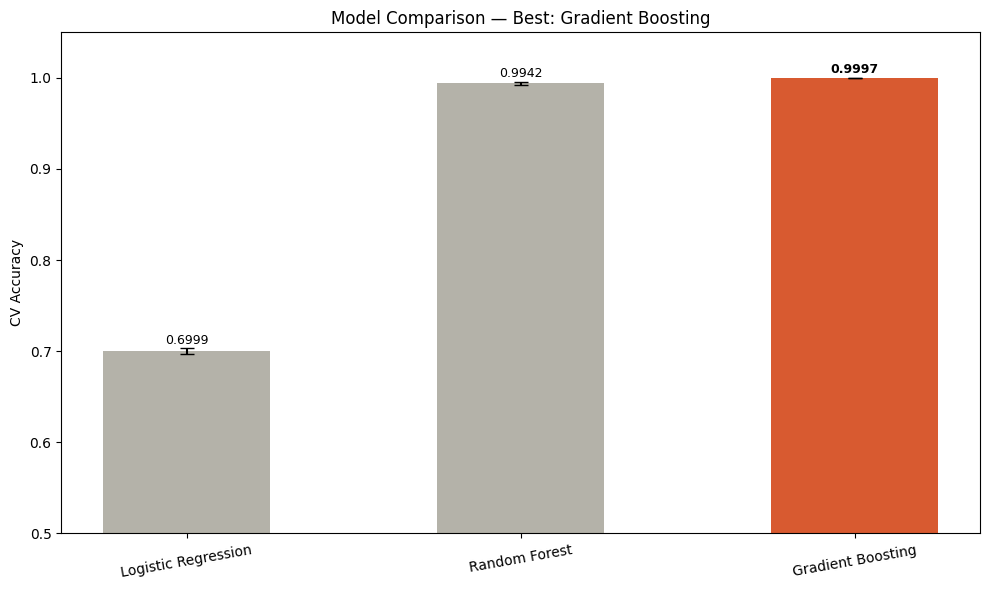

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(results.keys())
means = [results[m].mean() for m in model_names]
stds  = [results[m].std()  for m in model_names]
x_pos = np.arange(len(model_names))
bar_colors = ["#D85A30" if m == best_model_name else "#B4B2A9" for m in model_names]
ax.bar(x_pos, means, yerr=stds, color=bar_colors, capsize=5, width=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylabel("CV Accuracy")
ax.set_ylim(0.5, 1.05)
ax.set_title(f"Model Comparison — Best: {best_model_name}")
for i, (m, s) in enumerate(zip(means, stds)):
    weight = "bold" if model_names[i] == best_model_name else "normal"
    ax.text(i, m + s + 0.005, f"{m:.4f}", ha="center", fontsize=9, fontweight=weight)
plt.tight_layout()
plt.show()

In [28]:
feature_names = X.columns.tolist()
perm_imp = permutation_importance(
    best_model_pipeline, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_imp.importances_mean,
    "Std": perm_imp.importances_std
}).sort_values("Importance", ascending=False)

print("\nTop 15 Fitur Paling Berpengaruh:")
print(importance_df.head(15).to_string(index=False))


Top 15 Fitur Paling Berpengaruh:
                Feature  Importance      Std
   mental_health_status     0.26897 0.003254
           stress_level     0.25158 0.003821
         sleep_duration     0.22764 0.003882
physical_activity_level     0.15050 0.002018
      academic_pressure     0.14931 0.002140
            screen_time     0.08291 0.001346
                    bmi     0.00000 0.000000
             heart_rate     0.00000 0.000000
           water_intake     0.00000 0.000000
      exercise_duration     0.00000 0.000000
             step_count     0.00000 0.000000
    calorie_expenditure     0.00000 0.000000
          sleep_quality     0.00000 0.000000
              diet_type     0.00000 0.000000
         smoking_status     0.00000 0.000000


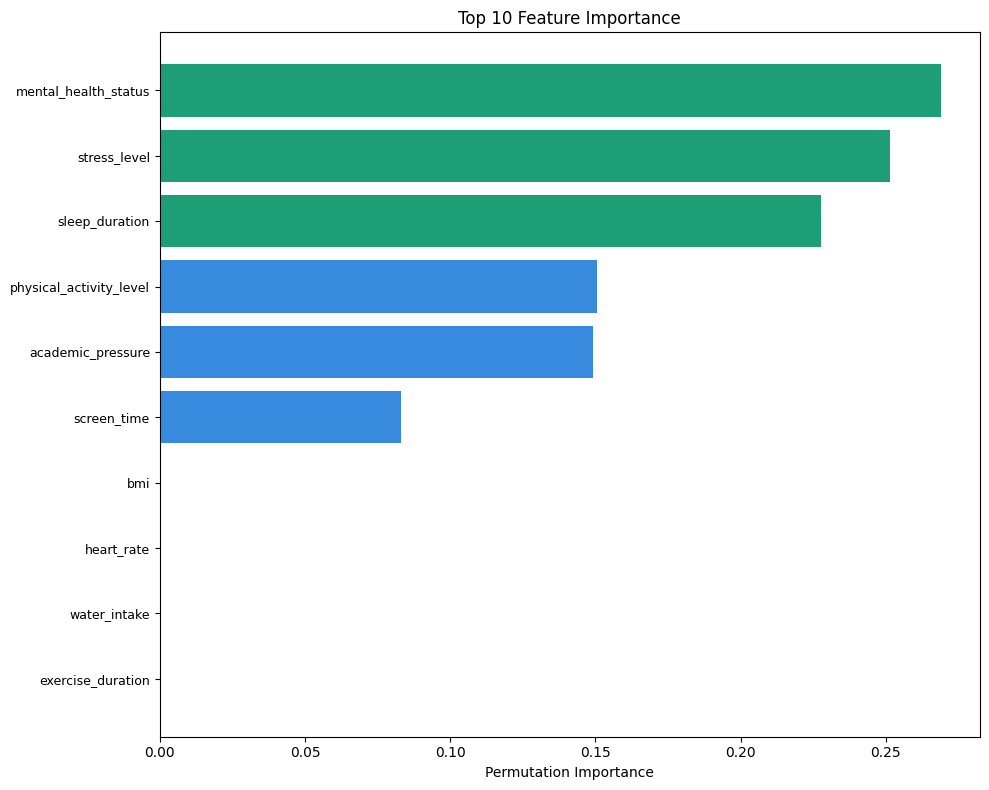

In [29]:
plt.figure(figsize=(10, 8))

top10 = importance_df.head(10)
colors = ["#1d9e75" if i < 3 else "#378add" if i < 7 else "#888780"
          for i in range(len(top10))]
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color=colors[::-1])
plt.xlabel("Permutation Importance")
plt.title("Top 10 Feature Importance")
plt.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()